# Reproducing plots in the paper

In this notebook, we reproduce several of the active volume and Toffoli plots shown in our work. For generating the circuit metrics for the baseline and improved circuits, see `generate_baseline_data.ipynb` and `generate_improved_data.ipynb`.

We recommend the user executes the cells in order.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import json
from collections import OrderedDict

from pathlib import Path


def load_json(path):
    with open(path) as f:
        return json.load(f)


import re

import matplotlib.pyplot as plt
from psiq_fh.wb_program.utils import extract_all


from process_callgraph_data import *

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",  # math font similar to Times
        "axes.labelsize": 22,  # x/y axis labels
        "axes.titlesize": 22,  # subplot titles
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
        "legend.title_fontsize": 24,
    }
)

annotate_fontsize = 14

cmap = plt.get_cmap("Set2")

In [3]:
# Set True to save the plots
save_plots = True

## Section 3: Results

#### Figure 2. Comparison of computational volume of 2D square Fermi-Hubbard ground-state energy estimation for the baseline and improved implementations against the logical qubit count

In this figure, we show circuit volume is a less representative metric for costing an algorithm on an active volume quantum computer (especially compared to the active volume metric). Using the active volume metric, however, we see that the improved circuit outperforms the baseline circuit for larger lattice sizes.

In [4]:
### Load data generated from other notebooks

n_hwp_batches = 1  # for a single batch
lattice_sizes = np.arange(4, 22, 2)

# Extract volume metrics
baseline_cv = np.asarray(
    load_json(f"paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/baseline_cv_total.json")
)
baseline_av = np.asarray(
    load_json(f"paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/baseline_av_total.json")
)
improved_av = np.asarray(
    load_json(f"paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/improved_av_total.json")
)

# Extract logical qubit counts
baseline_metrics = load_json(
    f"paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/baseline_circuit_expanded_metrics.json"
)
improved_metrics = load_json(
    f"paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/improved_circuit_expanded_metrics.json"
)
qbits_baseline = np.array([baseline_metrics[lattice]["qubit_highwater"] for lattice in baseline_metrics])
qbits_improved = np.array([improved_metrics[lattice]["qubit_highwater"] for lattice in improved_metrics])

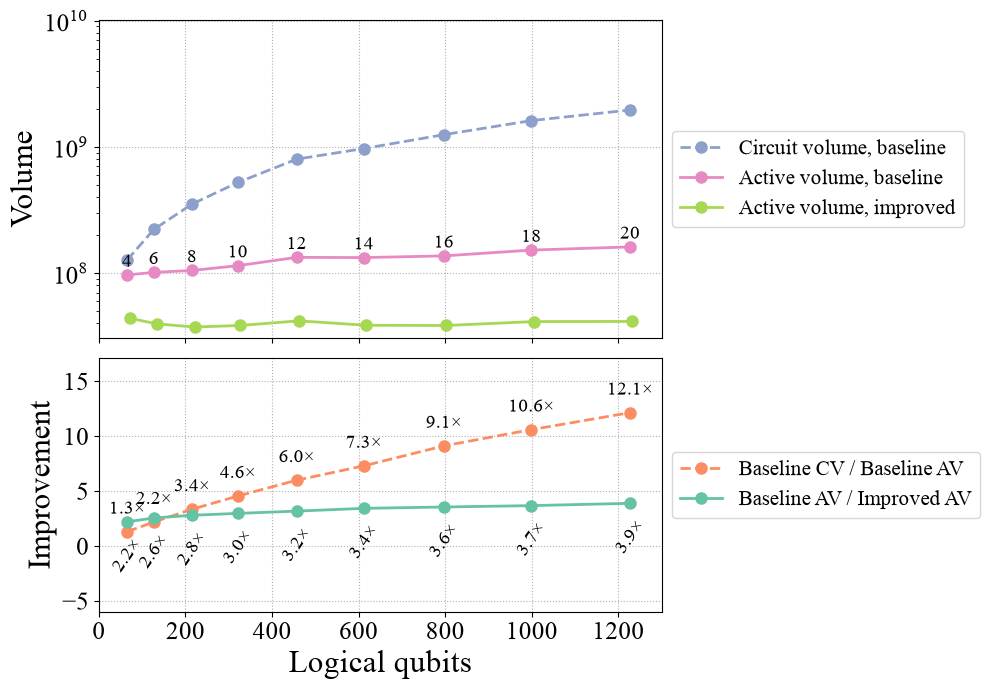

In [5]:
# Improvement ratios
cv_to_baseline_av = baseline_cv / baseline_av
baseline_to_improved_av = baseline_av / improved_av

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2.5, 2]})

# Top plot: volume vs. logical qubits
ax1.plot(qbits_baseline, baseline_cv, "o--", label="Circuit volume, baseline", color=cmap(2), markersize=8, lw=2)
ax1.plot(qbits_baseline, baseline_av, "o-", label="Active volume, baseline", color=cmap(3), markersize=8, lw=2)
ax1.plot(qbits_improved, improved_av, "o-", label="Active volume, improved", color=cmap(4), markersize=8, lw=2)

# Add lattice-size labels to the improved active-volume curve
for x, y, L in zip(qbits_baseline, baseline_av, lattice_sizes):
    ax1.annotate(str(L), (x, y), xytext=(0, 6), textcoords="offset points", ha="center", fontsize=annotate_fontsize)

ax1.set_yscale("log")
ax1.set_ylabel("Volume")
ax1.grid(linestyle=":")
ax1.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax1.set_ylim(top=1.01e10)

# Bottom plot: improvement
ax2.plot(qbits_baseline, cv_to_baseline_av, "o--", label="Baseline CV / Baseline AV", color=cmap(1), markersize=8, lw=2)
ax2.plot(
    qbits_baseline, baseline_to_improved_av, "o-", label="Baseline AV / Improved AV", color=cmap(0), markersize=8, lw=2
)

for x, y in zip(qbits_baseline, cv_to_baseline_av):
    ax2.annotate(
        f"{y:.1f}×",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=annotate_fontsize,
        color="black",
    )

for x, y in zip(qbits_baseline, baseline_to_improved_av):
    ax2.annotate(
        f"{y:.1f}×",
        (x, y),
        xytext=(0, -10),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=annotate_fontsize,
        rotation=55,
        color="black",
    )

ax2.set_ylabel("Improvement")
ax2.set_xlabel("Logical qubits")
ax2.grid(linestyle=":")
ax2.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ratio_max = max(cv_to_baseline_av.max(), baseline_to_improved_av.max())
ax2.set_ylim(-6, ratio_max + 5)
ax2.set_xlim(0, 1300)
plt.tight_layout()

if save_plots:
    plt.savefig(f"./paper_data_and_plots/volume_speedups.png", format="png", dpi=300)

#### Figure 3. Active volume (AV) breakdown

In these plots, we show the active volume breakdown for both baseline and improved circuits, by Clifford/non-Clifford split or by major subroutine. We use the data typically used to generate callgraphs.

In [6]:
# Baseline callgraph data
directory = Path(f"./paper_data_and_plots/baseline_callgraph_data/{n_hwp_batches}batches/")
files = sorted(
    (f for f in directory.iterdir() if f.is_file()), key=lambda f: int(re.search(r"(\d+)dim", f.name).group(1))
)
filepaths = [str(f) for f in files]

baseline_graph_list = [QreAnalysis.from_json(fpath) for fpath in filepaths]

# Improved callgraph data
directory = Path(f"./paper_data_and_plots/improved_callgraph_data/{n_hwp_batches}batches/")
files = sorted(
    (f for f in directory.iterdir() if f.is_file()), key=lambda f: int(re.search(r"(\d+)dim", f.name).group(1))
)
filepaths = [str(f) for f in files]

improved_graph_list = [QreAnalysis.from_json(fpath) for fpath in filepaths]

In [7]:
# Load Clifford/non-Clifford active volume data as well as their relative percentages
n_hwp_batches = 1

baseline_cliff_av = load_json(f"./paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/cliff_av.json")
baseline_noncliff_av = load_json(
    f"./paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/noncliff_av.json"
)
baseline_cliff_av_pct = load_json(
    f"./paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/pc_av_cliff_list.json"
)
baseline_noncliff_av_pct = load_json(
    f"./paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/pc_av_noncliff_list.json"
)
improved_cliff_av = load_json(f"./paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/cliff_av.json")
improved_noncliff_av = load_json(
    f"./paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/noncliff_av.json"
)
improved_cliff_av_pct = load_json(
    f"./paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/pc_av_cliff_list.json"
)
improved_noncliff_av_pct = load_json(
    f"./paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/pc_av_noncliff_list.json"
)

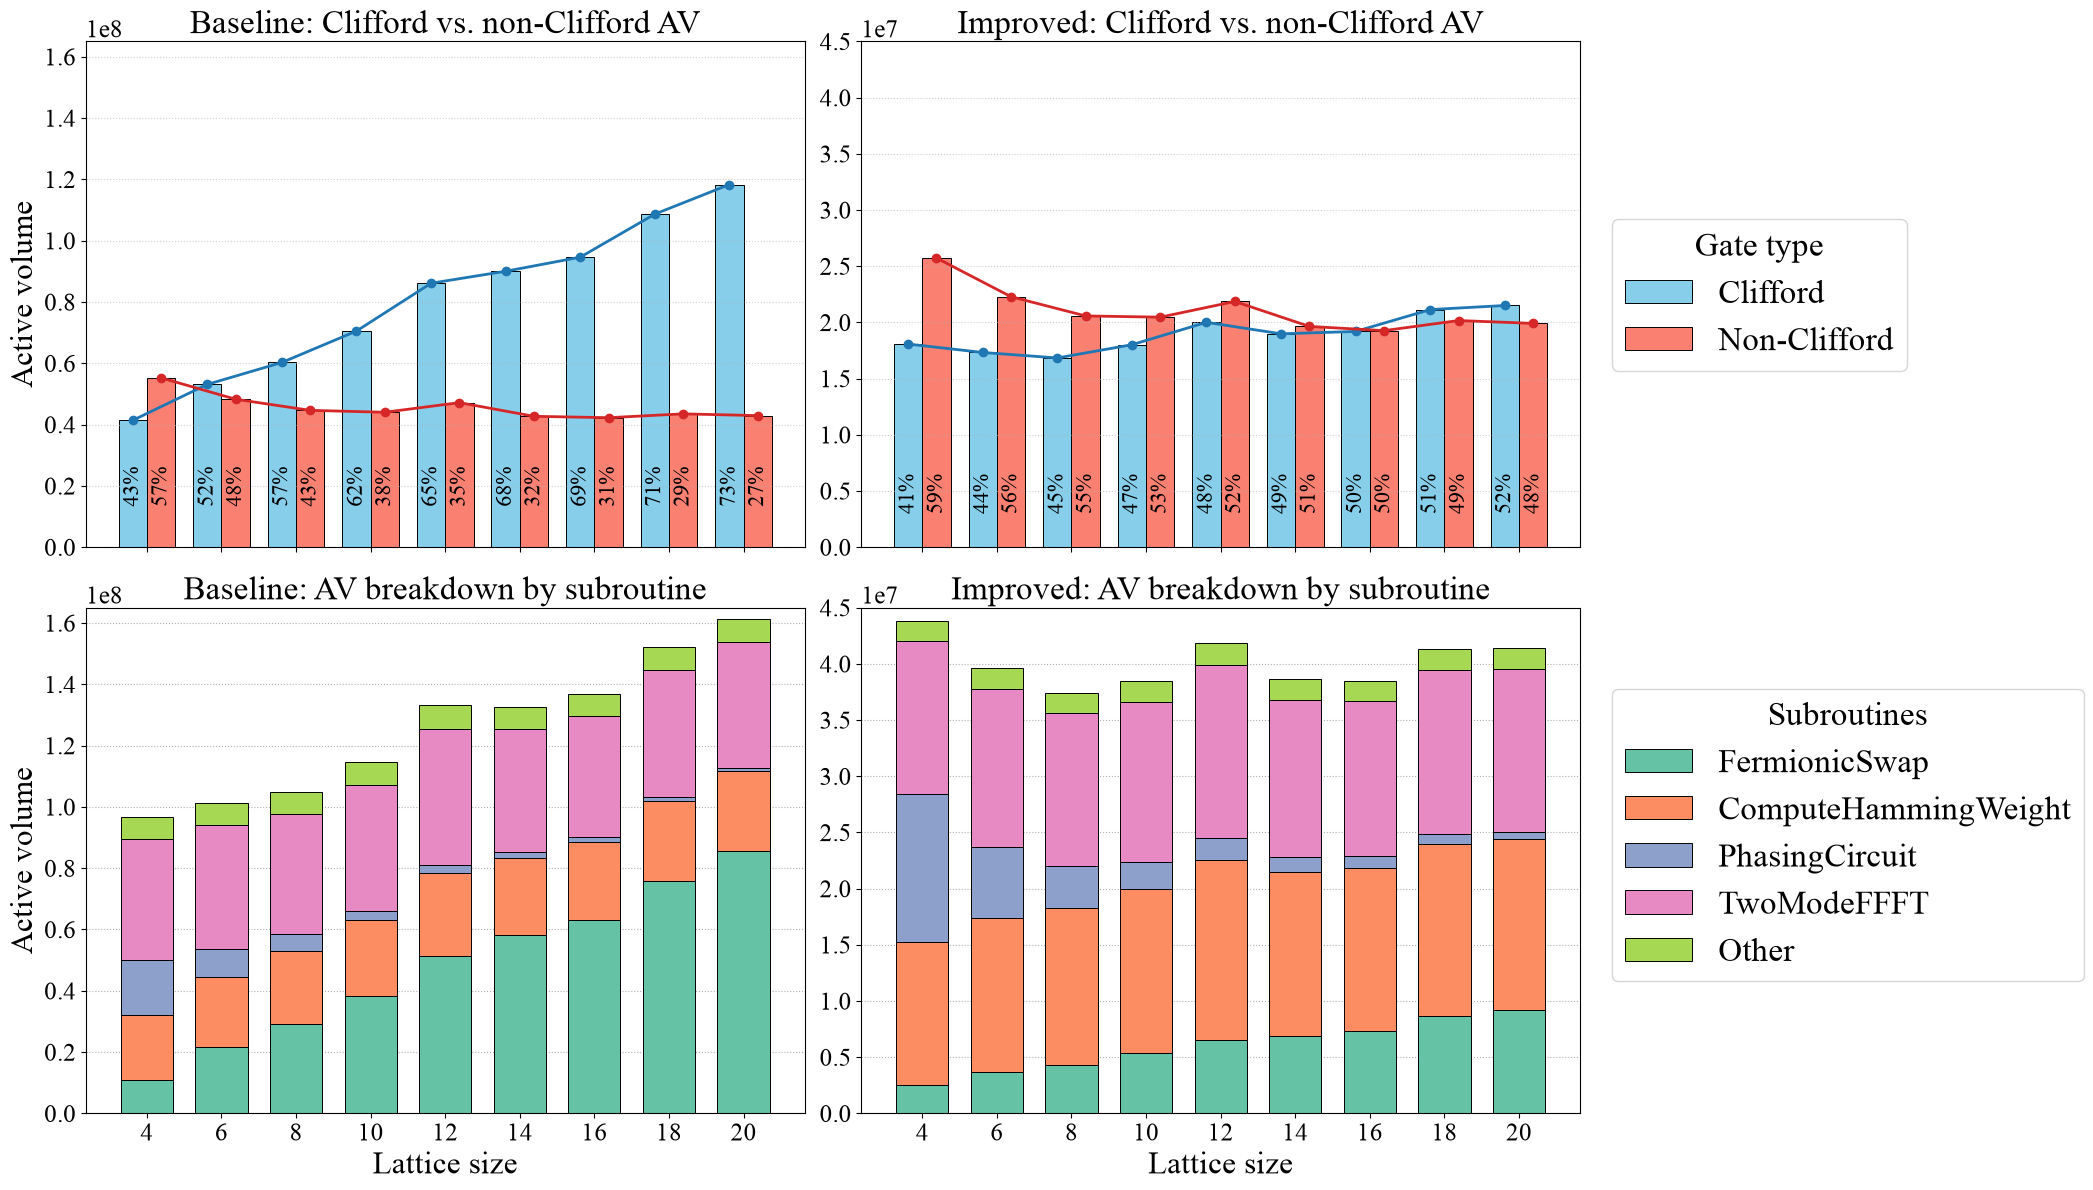

In [8]:
ylim_high_baseline = 1.65e8
ylim_high_improved = 4.5e7

lattice_sizes = np.arange(4, 22, 2)
x = np.arange(len(lattice_sizes))
bar_width = 0.38

groups = OrderedDict(
    [
        ("FermionicSwap", ("FermionicSwap",)),
        ("ComputeHammingWeight", ("ComputeHammingWeight",)),
        ("PhasingCircuit", ("PhasingCircuit",)),
        ("TwoModeFFFT", ("TwoModeFFFT",)),
    ]
)


def plot_clifford_nonclifford_av(
    ax,
    cliff_av,
    noncliff_av,
    cliff_av_pct,
    noncliff_av_pct,
    title,
    ylim_high=None,
    show_legend=True,
    show_ylabel=True,
    show_xlabel=True,
):
    """Plot Clifford and non-Clifford active volumes on an existing axis."""
    cliff_av = np.asarray(cliff_av)
    noncliff_av = np.asarray(noncliff_av)
    cliff_av_pct = np.asarray(cliff_av_pct)
    noncliff_av_pct = np.asarray(noncliff_av_pct)

    bars1 = ax.bar(
        x - bar_width / 2,
        cliff_av,
        width=bar_width,
        label="Clifford",
        color="skyblue",
        edgecolor="black",
        linewidth=0.7,
    )
    bars2 = ax.bar(
        x + bar_width / 2,
        noncliff_av,
        width=bar_width,
        label="Non-Clifford",
        color="salmon",
        edgecolor="black",
        linewidth=0.7,
    )

    # Connect the tops of each set of bars.
    ax.plot(x - bar_width / 2, cliff_av, color="tab:blue", marker="o", linewidth=2, zorder=3)
    ax.plot(x + bar_width / 2, noncliff_av, color="tab:red", marker="o", linewidth=2, zorder=3)

    # Put all percentage labels at a common vertical position.
    label_y = 0.10 * max(np.max(cliff_av), np.max(noncliff_av))

    for bar, percentage in zip(bars1, cliff_av_pct):
        ax.annotate(
            f"{percentage:.0f}%",
            xy=(bar.get_x() + bar.get_width() / 2, label_y),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=annotate_fontsize + 2,
        )

    for bar, percentage in zip(bars2, noncliff_av_pct):
        ax.annotate(
            f"{percentage:.0f}%",
            xy=(bar.get_x() + bar.get_width() / 2, label_y),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=annotate_fontsize + 2,
        )

    if show_xlabel:
        ax.set_xlabel("Lattice size")
    if show_ylabel:
        ax.set_ylabel("Active volume")
    ax.set_title(title, fontsize=24)
    if ylim_high:
        ax.set_ylim(0, ylim_high)
    ax.set_xticks(x)
    ax.set_xticklabels(lattice_sizes)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.grid(axis="y", alpha=0.6, linestyle=":")
    if show_legend:
        ax.legend()
    return ax


fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex="col", constrained_layout=True)
ax_baseline_breakdown = axes[1, 0]
ax_baseline_cliff = axes[0, 0]
ax_improved_breakdown = axes[1, 1]
ax_improved_cliff = axes[0, 1]

# Bottom row: circuit breakdowns by subroutine
ax_baseline_breakdown = plot_av_breakdown_over_lattice_sizes(
    baseline_graph_list,
    lattice_sizes,
    title="Baseline: AV breakdown by subroutine",
    granularity=("PhasingCircuit", ),
    groups=groups,
    ax=ax_baseline_breakdown,
    show_percentages=False,
    ylim_high=ylim_high_baseline,
    show_legend=False,
    show_xlabel=True,
    show_ylabel=True,
)

ax_improved_breakdown = plot_av_breakdown_over_lattice_sizes(
    improved_graph_list,
    lattice_sizes,
    title="Improved: AV breakdown by subroutine",
    granularity=("PhasingCircuit", "DirectionalPhasingCircuit"),
    groups=groups,
    ax=ax_improved_breakdown,
    show_percentages=False,
    ylim_high=ylim_high_improved,
    show_legend=False,
    show_xlabel=True,
    show_ylabel=False,
)

# Top row: Clifford vs. non-Clifford breakdowns
ax_baseline_cliff = plot_clifford_nonclifford_av(
    ax=ax_baseline_cliff,
    cliff_av=baseline_cliff_av,
    noncliff_av=baseline_noncliff_av,
    cliff_av_pct=baseline_cliff_av_pct,
    noncliff_av_pct=baseline_noncliff_av_pct,
    title="Baseline: Clifford vs. non-Clifford AV",
    ylim_high=ylim_high_baseline,
    show_legend=False,
    show_xlabel=False,
    show_ylabel=True,
)
ax_improved_cliff = plot_clifford_nonclifford_av(
    ax=ax_improved_cliff,
    cliff_av=improved_cliff_av,
    noncliff_av=improved_noncliff_av,
    cliff_av_pct=improved_cliff_av_pct,
    noncliff_av_pct=improved_noncliff_av_pct,
    title="Improved: Clifford vs. non-Clifford AV",
    ylim_high=ylim_high_improved,
    show_legend=False,
    show_xlabel=False,
    show_ylabel=False,
)

handles, labels = ax_improved_breakdown.get_legend_handles_labels()
fig.legend(
    handles, labels, title="Subroutines", loc="center left", bbox_to_anchor=(1.0, 0.3), frameon=True, fontsize=24
)

handles, labels = ax_improved_cliff.get_legend_handles_labels()
fig.legend(handles, labels, title="Gate type", loc="center left", bbox_to_anchor=(1.0, 0.75), frameon=True, fontsize=24)
fig.tight_layout()

if save_plots:
    fig.savefig(f"./paper_data_and_plots/av_breakdowns.png", format="png", dpi=300, bbox_inches="tight")

### Section 3: effects of batching

This is not a plot, but we note the changes in the active volume and qubit count when we use $\beta=4$ batches instead of $1$ in the main text in Section 3. We re-produce the numbers here.

In [9]:
improved_metrics_1batch = load_json(
    "paper_data_and_plots/improved_metrics_data/1batches/improved_circuit_expanded_metrics.json"
)
improved_metrics_4batch = load_json(
    "paper_data_and_plots/improved_metrics_data/4batches/improved_circuit_expanded_metrics.json"
)

qbits_improved_1batch = np.array(
    [improved_metrics_1batch[lattice]["qubit_highwater"] for lattice in improved_metrics_1batch]
)
av_improved_1batch = np.array([improved_metrics_1batch[lattice]["total_av"] for lattice in improved_metrics_1batch])

qbits_improved_4batch = np.array(
    [improved_metrics_4batch[lattice]["qubit_highwater"] for lattice in improved_metrics_4batch]
)
av_improved_4batch = np.array([improved_metrics_4batch[lattice]["total_av"] for lattice in improved_metrics_4batch])

# Qubits
qbit_change = (qbits_improved_4batch[-1] - qbits_improved_1batch[-1]) / qbits_improved_1batch[-1] * 100

# AV
av_change = (av_improved_4batch[-1] - av_improved_1batch[-1]) / av_improved_1batch[-1] * 100

print("QRE change from 1 batch to 4 batches:")
print(f"{qbit_change:.2f}% change in qubits")
print(f"{av_change:.2f}% change in active volume")

QRE change from 1 batch to 4 batches:
-24.84% change in qubits
3.05% change in active volume


#### Figure 5. Comparison of the total Toffoli counts between this work and those reported by Table 2 of [Campbell](https://arxiv.org/abs/2012.09238) and Supplementary Table 5 of [Kan et al.](https://arxiv.org/abs/2411.02160)

We compare the number of Toffoli gates from our circuits with those from past studies by Campbell and Kan et al. 

In [10]:
# Campbell (from Table II in arxiv:2012.09238)
campbell_L = [8, 10, 12, 14, 16, 18, 20]
campbell_logical_qubits = [162, 252, 362, 492, 642, 812, 1002]
campbell_toff = [4.3e5, 4.4e5, 4.6e5, 4.6e5, 4.6e5, 4.6e5, 4.7e5]
campbell_T = [4.1e6, 3.3e6, 2.9e6, 2.5e6, 2.3e6, 2.2e6, 2.0e6]
campbell_toff_cost = [toff + T / 2 for toff, T in zip(campbell_toff, campbell_T)]

# Kan et al. (from Supplementary Table 5 in arxiv:2411.02160)
kan_L = [4, 6, 8, 10, 12, 14, 16, 18, 20]
kan_logical_qubits = [55, 107, 181, 269, 383, 512, 667, 835, 1025]
kan_toff_cost = [1.23e6, 9.32e5, 8.79e5, 8.81e5, 8.86e5, 8.68e5, 8.63e5, 8.51e5, 8.54e5]

# Workbench counts
n_hwp_batches = 2
improved_data_2batches = load_json(
    f"paper_data_and_plots/improved_metrics_data/{n_hwp_batches}batches/improved_circuit_expanded_metrics.json"
)

wb_L = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20])
wb_toff_cost = extract_all(improved_data_2batches, "t_gates") / 2 + extract_all(
    improved_data_2batches, "aggregated_toff_count"
)
wb_logical_qubits = extract_all(improved_data_2batches, "qubit_highwater")  # number of logical qubits

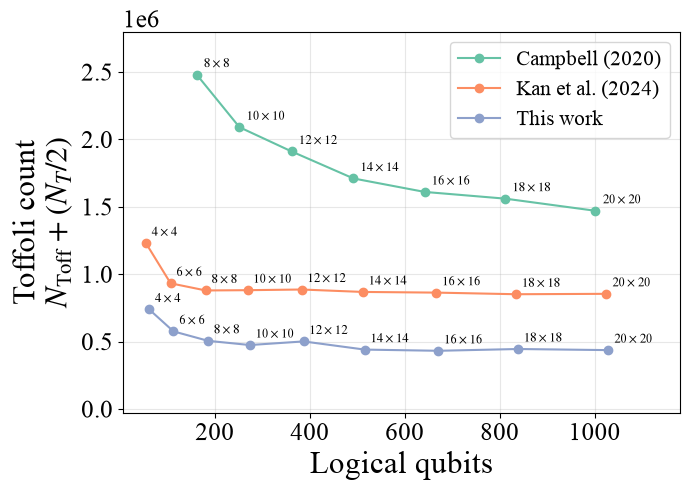

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(campbell_logical_qubits, campbell_toff_cost, marker="o", label="Campbell (2020)", color=cmap(0))
for x, y, L in zip(campbell_logical_qubits, campbell_toff_cost, campbell_L):
    plt.annotate(rf"${L}\times{L}$", (x, y), xytext=(5, 5), textcoords="offset points", fontsize=9)

### Kan et al
plt.plot(kan_logical_qubits, kan_toff_cost, marker="o", label="Kan et al. (2024)", color=cmap(1))
for x, y, L in zip(kan_logical_qubits, kan_toff_cost, kan_L):
    plt.annotate(rf"${L}\times{L}$", (x, y), xytext=(4, 5), textcoords="offset points", fontsize=9)

### Workbench
plt.plot(wb_logical_qubits, wb_toff_cost, marker="o", label="This work", color=cmap(2))
for x, y, L in zip(wb_logical_qubits, wb_toff_cost, wb_L):
    plt.annotate(rf"${L}\times{L}$", (x, y), xytext=(4, 5), textcoords="offset points", fontsize=9)

plt.ylim(bottom=-3e4, top=2.8e6)
plt.xlim(right=1180)
plt.xlabel("Logical qubits")
plt.ylabel(r"Toffoli count" + "\n" + r"$N_{\mathrm{Toff}} + (N_T/2)$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

if save_plots:
    plt.savefig("./paper_data_and_plots/toffs_comparison_beta2.png", format="png", dpi=300)

## Section 4: Compilation details

#### Figure 7. Comparing the number of queries between sine-windowed QPE versus the entanglement-free variant as a function of the allocated error budget for phase error

In this figure, we compare the number of queries between the sine-windowed QPE and entanglement-free QPE given the same error budget for phase error. The difference is expected because while entanglement-free QPE achieves Heisenberg scaling, it does not reach the minimum Holevo variance.

In [12]:
from psiq_fh.utils.qpe_utils import compute_n_queries


def compute_n_queries_wrapper(x, sin_window=True, dpkb=True, power_of_two=True):
    # All we need is for QPE_error * evolution_time = x
    QPE_error = x
    evolution_time = 1
    return compute_n_queries(QPE_error, evolution_time, sin_window, dpkb, power_of_two)

In [13]:
x_vals = np.linspace(0.01, 0.06, 1000)  # Reasonable values from existing data

queries_sine_spkb = compute_n_queries_wrapper(x_vals, sin_window=True, dpkb=False)
queries_berry_spkb = compute_n_queries_wrapper(x_vals, sin_window=False, dpkb=False)

queries_sine_dpkb = compute_n_queries_wrapper(x_vals, sin_window=True, dpkb=True)
queries_berry_dpkb = compute_n_queries_wrapper(x_vals, sin_window=False, dpkb=True)

queries_sine_spkb_nonpower_of_two = compute_n_queries_wrapper(x_vals, sin_window=True, dpkb=False, power_of_two=False)
queries_berry_spkb_nonpower_of_two = compute_n_queries_wrapper(x_vals, sin_window=False, dpkb=False, power_of_two=False)

queries_sine_dpkb_nonpower_of_two = compute_n_queries_wrapper(x_vals, sin_window=True, dpkb=True, power_of_two=False)
queries_berry_dpkb_nonpower_of_two = compute_n_queries_wrapper(x_vals, sin_window=False, dpkb=True, power_of_two=False)

32 96


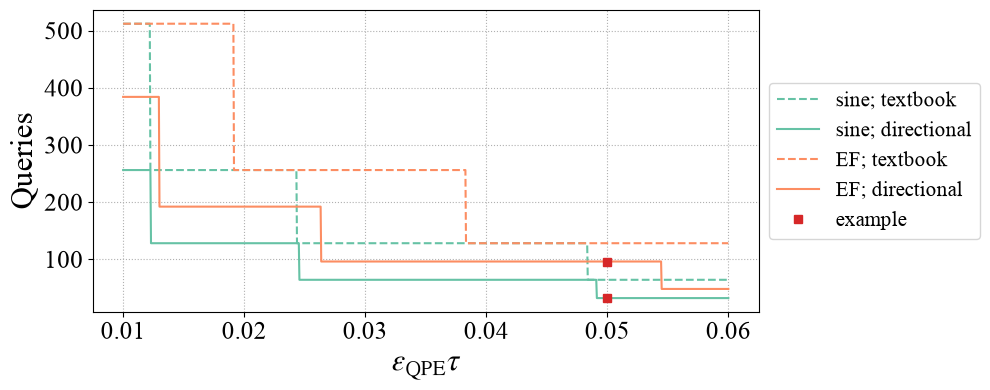

In [14]:
fig = plt.figure(figsize=(10, 4))

plt.plot(x_vals, queries_sine_spkb, "--", color=cmap(0), label="sine; textbook")
plt.plot(x_vals, queries_sine_dpkb, "-", color=cmap(0), label="sine; directional")

plt.plot(x_vals, queries_berry_spkb, "--", color=cmap(1), label="EF; textbook")
plt.plot(x_vals, queries_berry_dpkb, "-", color=cmap(1), label="EF; directional")

x_example = 0.05
sin_pt = (x_example, compute_n_queries_wrapper(x_example, sin_window=True, dpkb=True))
ef_pt = (x_example, compute_n_queries_wrapper(x_example, sin_window=False, dpkb=True))
plt.plot([sin_pt[0], ef_pt[0]], [sin_pt[1], ef_pt[1]], "s", color="tab:red", label="example")
print(sin_pt[1], ef_pt[1])
plt.xlabel(r"$\epsilon_\text{QPE} \tau$")
plt.ylabel(r"Queries")
plt.grid(linestyle=":")

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

if save_plots:
    plt.savefig(f"./paper_data_and_plots/qpe_queries.png", format="png", dpi=300)

### Section 4.4.1

Estimating active volume of the control structure for QPE employing directionally controlled unitaries

In the main text, we estimate the additional active volume required for the query control structures alone. For the chosen sine-windowed QPE, the numbers of (closed)-controlled and directionally controlled applications of $U$ are known. From here, we compute the active volumes of the gates we need to implement these controlled and bidirectionally-controlled versions of $U$.

In [15]:
from psiqdk.workbench.experimental._active_volume_estimation._av_counting._active_volume_lookup import (
    op_av_lookup_table,
)
from psiqdk.workbench.experimental._active_volume_estimation._av_counting._qpu_op_functions import (
    _get_multi_target_cx_av,
)
from psiqdk.workbench.experimental._active_volume_estimation._av_counting._ppr_functions import (
    get_magnitude_approximation_av,
)
from psiqdk.workbench.ops import QPU_op
import psiqdk.workbench.opcodes._opcode_constants as opc
from psiqdk.workbench.qre._op import Op

In [16]:
### Active volume of gates needed to implement controlled and bidirectionally-controlled versions of $U$

# CNOT
cnot_op = QPU_op(opcode=opc.OP_qc_x, target=2, condition=1)
cnot_av = op_av_lookup_table[cnot_op]

# Toffoli
toff_op = QPU_op(opcode=opc.OP_qc_x, target=4, condition=3)
toff_av = op_av_lookup_table[toff_op]

# Elbows
lelbow_op = QPU_op(opcode=opc.OP_qc_lelbow, target=4, condition=3)
lelbow_av = op_av_lookup_table[lelbow_op]
relbow_op = QPU_op(opcode=opc.OP_qc_lelbow, target=4, condition=3)
relbow_av = op_av_lookup_table[relbow_op]

# Rotation
epsilon = 0.001  # reasonable value based on data; log-scaling anyway
rot_op = Op(args={"x_weight": 0, "y_weight": 0, "z_weight": 1, "error_param": epsilon})
rot_av = get_magnitude_approximation_av(rot_op)

In [17]:
def compute_additional_cost(r, k, L):
    """Compute additional AV from control structure.

    Args:
        r (int): Number of Trotter steps
        k (int): Number of phase qubits in QPE using directional controlled unitaries
        L (int): Lattice size
    """
    flog = int(np.floor(np.log2(L**2)))

    av = 0
    ### First phase qubit

    # one left and right elbow for controlling the payload rotation in the center term
    av += lelbow_av
    av += relbow_av

    # controlling adder-like circuit
    av += (flog + 1) * toff_av

    # one Rz rotation for phase fixup
    av += rot_av

    # CNOTs for directional control of payload rotations in HWP calls
    av += 2 * r * 2 * cnot_av

    # two CNOT fanouts with target size 2log2(L**2) + 3 qubits
    av += 2 * _get_multi_target_cx_av(2 * flog + 3)

    ### Remaining k-1 phase qubits

    # CNOTs from directional control of payload rotatioins in HWP calls
    multiplicity = r * 2 ** (k + 1) - 4 * r + k + 1
    av += multiplicity * 2 * cnot_av

    # CNOT fanouts with target size 2log2(L**2) + 3 qubits
    multiplicity = 2 * (k - 1)
    av += multiplicity * _get_multi_target_cx_av(2 * flog + 3)

    # GPGA
    av += (k - 1) * toff_av
    av += rot_av
    av += (k - 1) * rot_av
    return av


# Additional cost for QPE control structure for 20x20 lattice with 6 phase qubits and 4 Trotter steps
r = 4
k = 6
L = 20
additional_blocks = compute_additional_cost(r=4, k=6, L=20)

print(
    f"For {L}x{L} lattice with {k} phase qubits and {r} Trotter steps, the additional active volume is {additional_blocks} blocks."
)

For 20x20 lattice with 6 phase qubits and 4 Trotter steps, the additional active volume is 7183.25 blocks.


### Figure 13. Decompositions and costs of non-local fSWAP operations

In this figure, we compute the active volume of different decompositions of the non-local fermionic swap operations. We can see the crossover point at $n=5$.

In [18]:
from psiq_fh.trotterization.fswapping.fermionic_swap import (
    av_decomp1_fswap,
    av_decomp2_fswap,
    av_naive_decomp,
)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [19]:
# Collect active volume data for different decompositions
n_scan = [i for i in range(3, 30)]

av_naive = [av_naive_decomp(n) for n in n_scan]
av_1_byhand = [av_decomp1_fswap(n) for n in n_scan]
av_2_byhand = [av_decomp2_fswap(n) for n in n_scan]

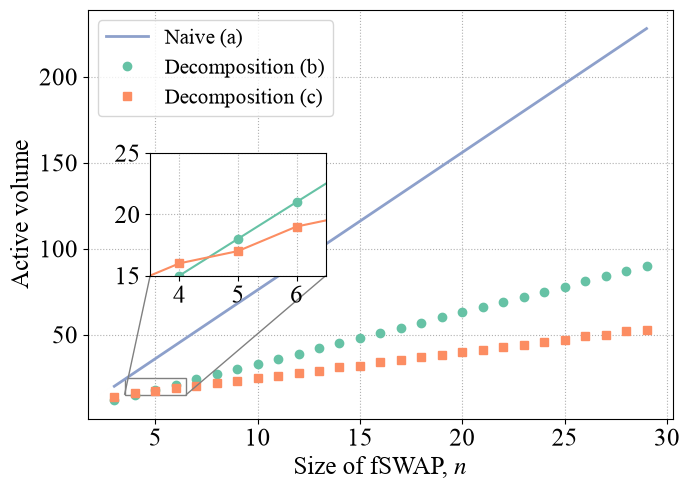

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(n_scan, av_naive, label="Naive (a)", color=cmap(2), lw=2)
ax.plot(n_scan, av_1_byhand, "o", color=cmap(0), label="Decomposition (b)")
ax.plot(n_scan, av_2_byhand, "s", color=cmap(1), label="Decomposition (c)")

ax.set_xlabel(r"Size of fSWAP, $n$", fontsize=18)
ax.set_ylabel(r"Active volume", fontsize=18)
ax.grid(linestyle=":")
ax.legend()
plt.tight_layout()

# Create inset
axins = inset_axes(ax, width="30%", height="30%", loc="center left", borderpad=3)
axins.plot(n_scan, av_1_byhand, "o-", color=cmap(0))
axins.plot(n_scan, av_2_byhand, "s-", color=cmap(1))

# Zoom in around the crossover point
axins.set_xlim(3.5, 6.5)
axins.set_ylim(15, 25)
axins.grid(linestyle=":")
axins.set_xticks([4, 5, 6])

# Draw lines to show zoomed region
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.5")
plt.tight_layout()

if save_plots:
    plt.savefig(f"./paper_data_and_plots/fswap_comparisons.png", format="png", dpi=300)

### Figure 16 (top): Resource counts at 20 x 20 versus the number of ancillae in batched Hamming weight phasing for a single interaction term in the Trotterized time evolution operator.

In this figure, we plot the active volume of the interaction term as we change the number of batches ($\beta$) in Hamming weight phasing. In the cells below, we instantiate the interaction term for different $\beta$ values and count their active volumes. To have a fair comparison, we set the overall error over all rotations to $10^{-2}$.

In [21]:
from psiqdk.workbench.compilation.filters.elementary_filters import RossSelingerSynthFilter
from psiqdk.workbench.compilation.filters.elementary_filters._single_control import SingleControlFilter

from psiqdk.workbench.rotations._rotation import RotationViaMixedFallback

from psiq_fh.trotterization.directional_hamming_weight_phasing import (
    PowerOfTwoBatchedDirectionalHammingWeightPhasing,
)
from psiq_fh.trotterization.catalyst_allocation import fetch_catalyst_qubits
from psiqdk.algorithms import ComputeHammingWeightGroupOfThrees
from psiq_fh.utils.jw_ordering_utils import generate_high_low_enum
from psiq_fh.trotterization.fermi_hubbard_data import InteractionTermData
from psiq_fh.trotterization.interaction import InteractionTrotterStep
from psiqdk.workbench.qre import resource_estimator
from psiq_fh.utils.fermi_hubbard_hamiltonian import get_expected_norm

from psiqdk.workbench.check_ops import is_phase
from psiqdk.workbench import QPU, Qubits


def is_rz(opcode):
    return opcode in [opc.OP_qc_rz]


def my_extra_cond(op):
    """Extra conds for our case.

    Note:
        - We don't want PPRs to be decomposed then treated with mixed fallback.
    """
    cond = is_phase(op.opcode) or is_rz(op.opcode)
    return [cond]

In [22]:
lattice_size = 20

batches = [2**k for k in range(6)]
use_black_box = True

# Total rotation error budget: synth_error_per_rot * num_rotations <= this value
TOTAL_ROTATION_SYNTH_ERROR = 0.01

In [23]:
%%time

blocks = []
qubits = []
toffs = []

norm = get_expected_norm(lattice_size, lattice_size, potential_coefficient=8, particle_hole_symmetry=True)

for n_batches in batches:
    number_spin_sites = 2 * (lattice_size * lattice_size)
    total_num_qubits = number_spin_sites * 2 + 4

    rot_filter = RossSelingerSynthFilter()
    rot_filter.synth_qbk = RotationViaMixedFallback(use_black_box=use_black_box)
    # update filter with extra conditions (we need this to prevent decomposing PPRs)
    rot_filter.extra_conds = my_extra_cond

    single_ctrl_filter = SingleControlFilter(use_anc=True)

    # Set up QPU instance:
    qc = QPU(
        pre_filters=[
            ">>clean-ladder-filter>>",
            single_ctrl_filter,
            rot_filter,
            ">>witness>>",
        ],
        filters=[">>buffer>>"],
    )
    qc.reset(total_num_qubits)

    psi_reg = Qubits(number_spin_sites, "psi", qc)

    evolution_time = 0.1
    number_of_trotter_steps = 1
    potential_coefficient = 8

    if n_batches:
        hw_qbk = ComputeHammingWeightGroupOfThrees()
        hwp_qbk = PowerOfTwoBatchedDirectionalHammingWeightPhasing(
            hw_qbk,
            n_hwp_batches=n_batches,
            rot_is_rz=True,
            preserve_global_phase=False,
            turn_on_cnots=False,
            use_black_box=use_black_box,  # blackbox for adder segments
        )
    else:
        hwp_qbk = None

    enumeration = list(generate_high_low_enum(lattice_size, pink_happy=True))
    normalized_term_coefficient = potential_coefficient / (4 * norm)

    interaction_data = InteractionTermData(enumeration, evolution_time, normalized_term_coefficient)
    interaction_trotter_step = InteractionTrotterStep(batched_hamming_weight_phasing_qubrick=hwp_qbk)

    # Get epsilon per rotation
    num_rots = (
        int(np.floor(np.log2(lattice_size**2 / n_batches))) + 1 + n_batches
    )  # catalyst rotations and n_batches number of payload rotations
    error_per_rot = TOTAL_ROTATION_SYNTH_ERROR / num_rots

    with qc.override_rotation_epsilon(error_per_rot):
        with qc.override_catalyst_rotation_epsilon(error_per_rot):
            interaction_trotter_step.compute(psi_reg, interaction_data)

    metrics = resource_estimator(qc).resources(expanded=True)
    blocks.append(metrics["active_volume"])

    # Check number of catalyst qubits
    cats = fetch_catalyst_qubits(qc)
    n_catalyst_rotations = int(np.floor(np.log2(lattice_size * lattice_size / n_batches)) + 1)
    assert cats.num_qubits == n_catalyst_rotations

    # Number of ancillae (not system qubits nor catalyst qubits)
    qubits.append(metrics["qubit_highwater"] - psi_reg.num_qubits - n_catalyst_rotations)
    toffs.append(metrics["aggregated_toff_count"])

    print(f"n_batches = {n_batches} done!")

n_batches = 1 done!
n_batches = 2 done!
n_batches = 4 done!
n_batches = 8 done!
n_batches = 16 done!
n_batches = 32 done!
CPU times: user 1.33 s, sys: 17.5 ms, total: 1.35 s
Wall time: 1.35 s


In [24]:
### Before we plot, let's verify the number of Toffolis matches the analytical expression

# Analytical expression
def hw_toff(n_rots_hwp):
    """Number of Toffolis for computing the Hamming weight."""
    return int(n_rots_hwp) - int(n_rots_hwp).bit_count()


toffs_validate = []
for n_batches in batches:
    # Toffolis from catalyst addition
    nTof_cat = n_batches * (np.floor(np.log2(lattice_size**2 / n_batches)) + 1)

    # Toffolis from Hamming weight computation
    nTof_hw = n_batches * hw_toff(n_rots_hwp=lattice_size**2 / n_batches)

    toffs_validate.append(int(nTof_cat + nTof_hw))

assert np.allclose(toffs_validate, toffs)

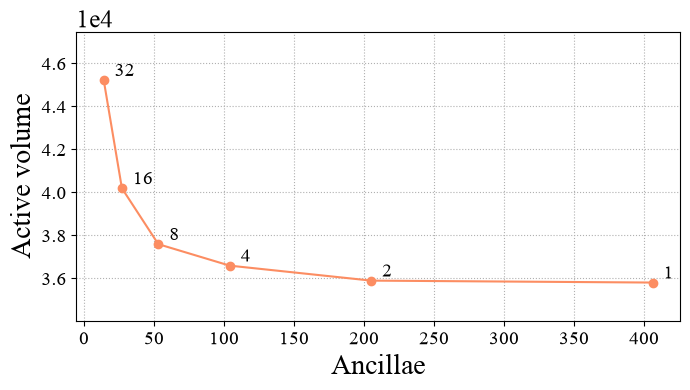

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharex=True)
ax = axes
ax.plot(qubits, blocks, "o-", color=cmap(1))
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

ax.set_ylabel("Active volume", fontsize=20)
ax.set_xlabel("Ancillae", fontsize=20)
ax.tick_params(axis="both", labelsize=14)

for x, y, b in zip(qubits, blocks, batches):
    ax.annotate(f"{b}", (x, y), textcoords="offset points", xytext=(8, 3), color="black", fontsize=14)

ax.set_ylim(bottom=min(blocks) - min(blocks) / 20, top=max(blocks) + max(blocks) / 20)
ax.grid(linestyle=":")
plt.tight_layout()

if save_plots:
    plt.savefig(f"./paper_data_and_plots/batching_20x20_data.png", format="png", dpi=300)

## Appendix D

### Figure 37. Comparison of the expression for the total number of Toffoli gates in Kan et al. and the Toffoli gates counted from the corresponding baseline circuit constructed using Workbench

We reproduce the plot verifying the Toffoli counts.

In [26]:
n_hwp_batches = 1

baseline_data = load_json(
    f"paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/baseline_toffs_total.json"
)
kan_data = load_json(f"paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/kan_toffs_total.json")

lattice_sizes = np.asarray(list(kan_data.keys()))
kan_toffs = np.asarray(list(kan_data.values()))
baseline_toffs = np.asarray(list(baseline_data.values()))

# Difference in Toffoli counts (should be zero)
print(abs(kan_toffs - baseline_toffs))

[0.00000000e+00 1.16415322e-10 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


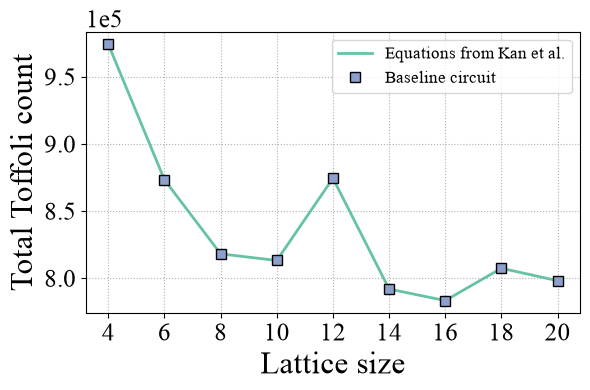

In [27]:
plt.figure(figsize=(6, 4))
plt.plot(lattice_sizes, kan_toffs, color=cmap(0), lw=2, label="Equations from Kan et al.")
plt.plot(lattice_sizes, baseline_toffs, "s", color=cmap(2), markersize=7, markeredgecolor="k", label="Baseline circuit")
plt.legend(fontsize=12)
plt.ylabel("Total Toffoli count")
plt.xlabel("Lattice size")
plt.grid(linestyle=":")
plt.xticks(lattice_sizes)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.tight_layout()

if save_plots:
    plt.savefig(f"./paper_data_and_plots/toffoli_count_comparison.png", format="png", dpi=300)